# Continuous Time Finance 1

This notebook begins the continuous-time finance coursework with Brownian motion, geometric Brownian motion, simulation, and distribution-based exercises.

It introduces the probabilistic tools used in the later continuous-time notebook.


In [795]:
import numpy as np
import pandas as pd
import scipy.stats as scs
import matplotlib.pyplot as plt

### Ex 1.1 (a)

In [4]:
def BM(T, n, N):
    dt = T/n
    #increments
    inc = np.random.normal(0, np.sqrt(dt), size = (N,n))
    #building brownian motion by cumulative summation
    path=np.cumsum(inc,axis=1)
    #add W_0 column
    zero=np.zeros((N,1))
    bm = np.hstack([zero,path])
    return bm

### Ex 1.1 (b)

In [6]:
T0=10
n0=1000
N0=10000

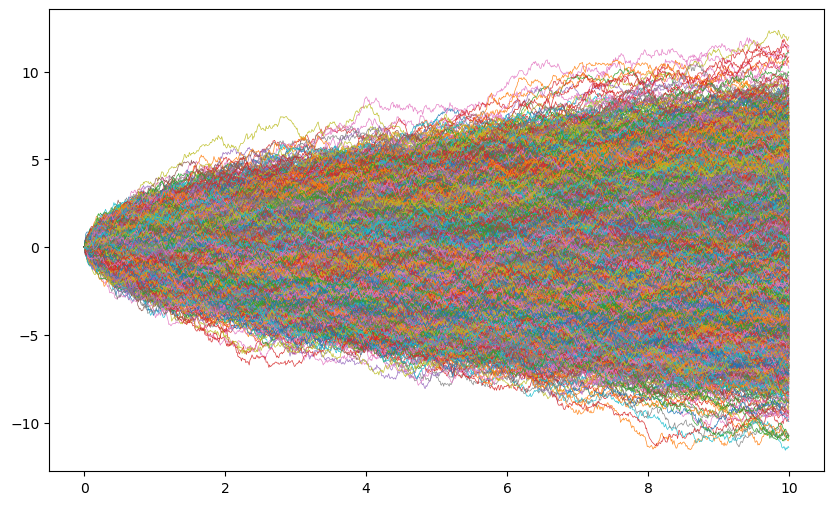

In [8]:
np.random.seed(1)
bm1=BM(T0,n0,N0)
t = np.linspace(0, T0, n0 + 1)
plt.figure(figsize=(10, 6))
plt.plot(t, bm1.T, lw=.5, alpha=.9)
plt.show()

### Ex 1.1 (c)

In [10]:
i=533
t_i=i*T0/n0
bm_sampl = bm1[:, i]

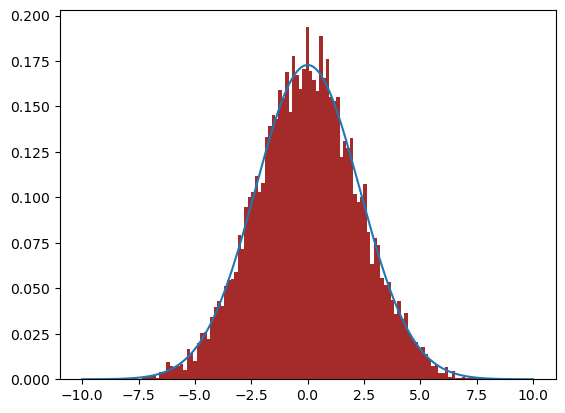

In [12]:
#density histogram of the t_i path sample
plt.hist(bm_sampl, bins = 100, density=True, color="brown")
#empirical density
x=np.linspace(-10,10,N0)
y= norm.pdf(x, loc=0, scale=np.sqrt(t_i))
plt.plot(x, y)
plt.show()

### Ex 1.2 (a)

In [14]:
P0=100
miu1=0.04
sigma1=0.2

In [16]:
def GBM(miu, sigma, T, P0, n, N):
    #brownian motion from 1.1
    dt=T/n
    increments = np.random.normal(0, np.sqrt(dt), size = (N,n))
    brownianPath=np.cumsum(increments,axis=1)
    zero=np.zeros((N,1))
    bm = np.hstack([zero,brownianPath])

    #Prices
    pt=np.zeros((N,n+1))
    for i in range(N):
        for j in range (n+1):
            pt[i,j]=P0 * np.exp((miu-1/2*sigma**2)*dt*j + sigma*bm[i,j])    
    return pt

In [18]:
N1=1000
T1=10
n1=2500

### 1.2 (b)

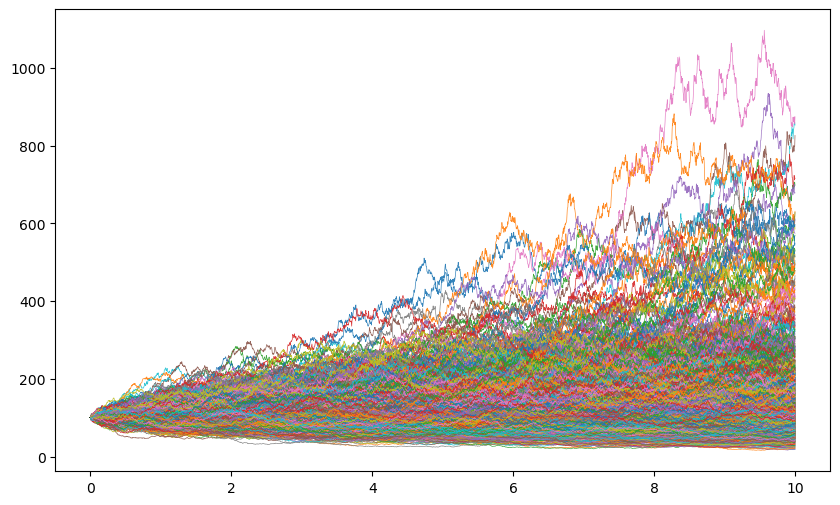

In [22]:
np.random.seed(1)
gmb1=GBM(miu1, sigma1, T1, P0, n1, N1)
t = np.linspace(0, T0, n1 + 1)
plt.figure(figsize=(10, 6))
plt.plot(t, gmb1.T, lw=.5, alpha=.9)
plt.show()

In [24]:
#First of N payh
PPath=gmb1[:1]

### 1.2 (c)

In [308]:
logReturns =np.diff(np.log(PPath),axis=1)
#column of zeros matching the number of rows
zero_col = np.zeros((PPath.shape[0], 1)) 

# Stack
logReturns = np.hstack([zero_col, logReturns]).flatten()

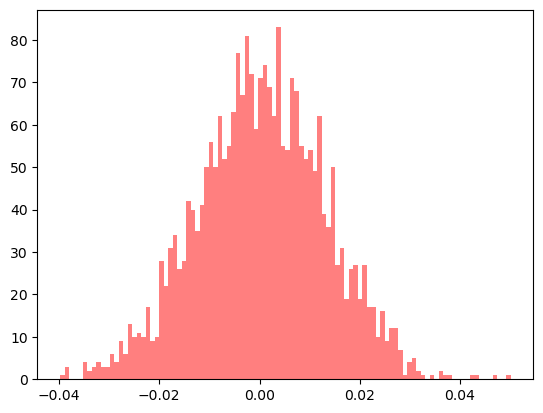

In [793]:
plt.hist( logReturns,bins=100, alpha=0.5, color='red')
plt.show()

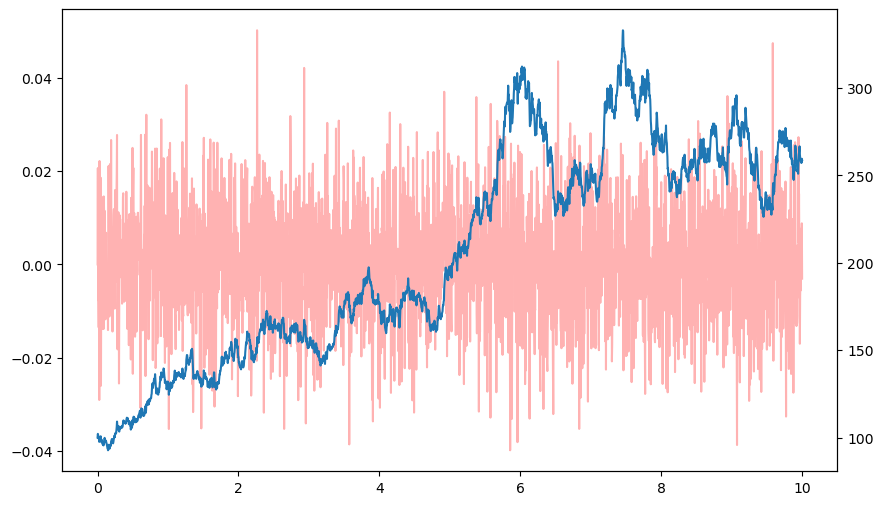

In [783]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
ax1.plot(t, logReturns.T, alpha=0.3, color='red')
ax2.plot(t,PPath.T)
plt.show()

### 1.2 (d)

In [313]:
stats = pd.DataFrame(data =[np.mean(logReturns)*250, np.std(logReturns)*np.sqrt(250), scs.skew(logReturns), scs.kurtosis(logReturns), np.mean(logReturns)/(T1/n1)+0.5*np.std(logReturns)**2, np.sqrt(np.std(logReturns)**2/(T1/n1))],
                     index=[ 'Empirical Mean', 'Empirical Volatility', 'Skewness', 'Kurtosis', 'Expected Mean', 'Expected Volatility'],
                     columns=['Statistics'])
print(stats)

                      Statistics
Empirical Mean          0.095001
Empirical Volatility    0.200803
Skewness               -0.019105
Kurtosis                0.019973
Expected Mean           0.095082
Expected Volatility     0.200803


### 1.2 (e)

In [165]:
Zti= (logReturns - np.mean(logReturns))/np.std(logReturns)

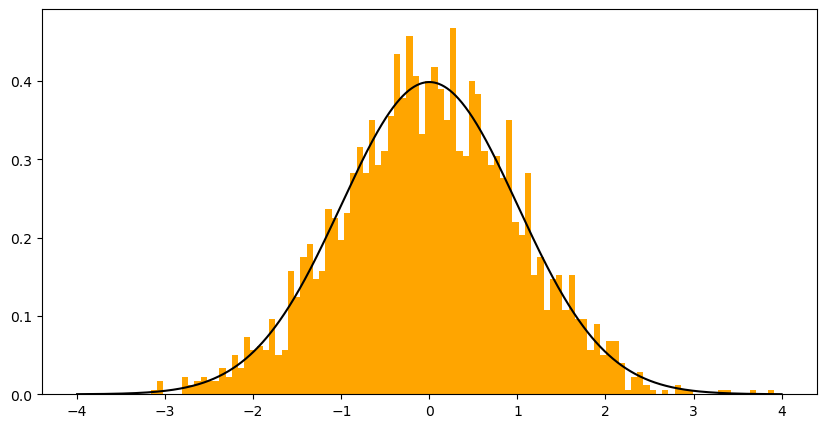

In [256]:
#density histogram of the t_i path sample
plt.figure(figsize=(10, 5))
plt.hist(Zti, bins=100,density=True, color = "orange")
#empirical density
a=np.linspace(-4,4,N1)
b= norm.pdf(a, loc=0)
plt.plot(a, b,color="black")
plt.show()

### 1.2 (f)

In [542]:
def rollingVol(LR, dt):
    rolling_vol = np.full(len(LR), np.nan)
    for i in range (250, len(LR)):
        mean =np.mean(LR[i-250:i])
        var = 1/250 * sum((LR[i-250:i]-mean)**2)
        rolling_vol[i] = (1 / np.sqrt(dt)) * np.sqrt(var)
    
    return rolling_vol

In [544]:
rollVol = rollingVol(logReturns, T1/n1)

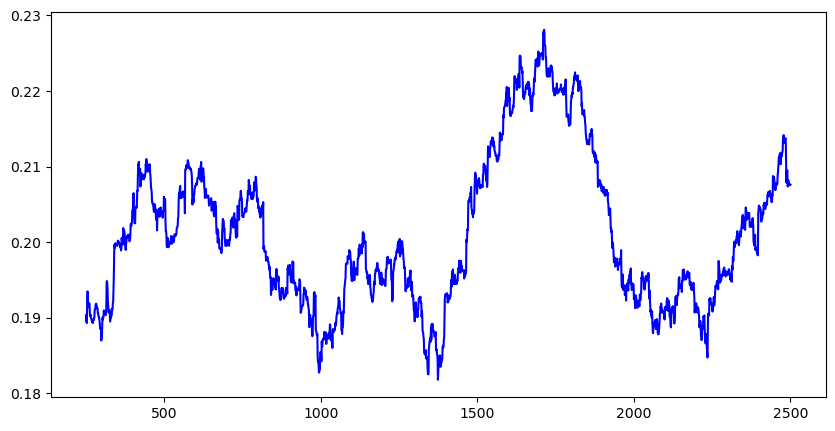

In [546]:
plt.figure(figsize=(10, 5))
plt.plot(rollVol, color='blue')
plt.show()

### 1.2 (g)

In [275]:
num_jumps = np.sum(np.abs(np.ravel(logReturns)[1:]) > 0.05)
print("Number of jumps:", num_jumps)

Number of jumps: 1


### 1.3 (a)

In [278]:
import yfinance as yf

In [280]:
spy = yf.download("SPY", start = "2020-01-01", end= "2026-03-30")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


### 1.3 (b)

In [556]:
Close =  spy.loc[:,"Close"].copy()

In [576]:
Close["LR"]=np.log(Close.SPY.pct_change()+1)
Close=Close.dropna()

In [326]:
dt1=1/250

### 1.3 (c)

### Stochastic Volatility

In [560]:
rets = Close.LR.dropna().to_numpy()

In [592]:
rollVol1= rollingVol(rets, dt1)

In [594]:
Close['Rolling Volatility']=rollVol1

C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_7932\594215230.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Close['Rolling Volatility']=rollVol1


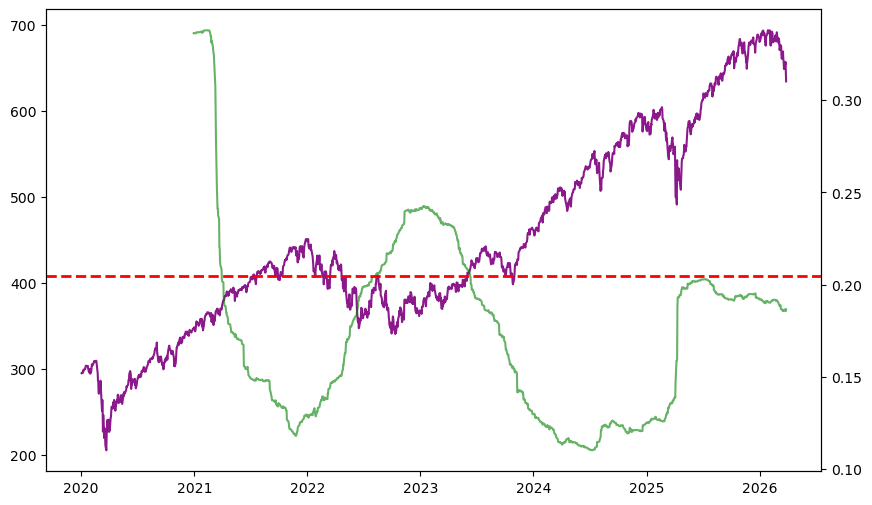

In [637]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
ax1.plot(Close.index, Close.SPY, alpha=0.9, color='purple')
ax2.plot(Close.index,Close['Rolling Volatility'], alpha=0.6,color="green")
plt.axhline(y=np.std(rets) * np.sqrt(250), color='red', linestyle='--', linewidth=2)
plt.show()

### Non-Normality

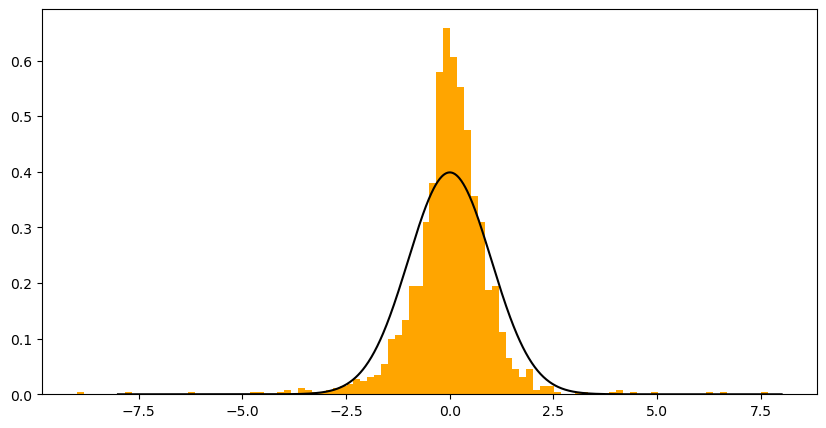

In [474]:
#standardized
Zti1 = (rets - np.mean(rets)) / np.std(rets)

plt.figure(figsize=(10, 5))

plt.hist(Zti1, bins=100, density=True, color="orange",)

a = np.linspace(-8, 8, 1350)
b = norm.pdf(a, loc=0)
plt.plot(a, b, color="black")
plt.show()

In [449]:
print('Empirical Skewness:', scs.skew(rets).round(4))
print("Empirical Kurtosis:", scs.kurtosis(rets).round(4))
print('Brownian Skewness:', scs.skew(logReturns).round(4))
print("Brownian Kurtosis:", scs.kurtosis(logReturns).round(4))


Empirical Skewness: -0.5502
Empirical Kurtosis: 13.5055
Brownian Skewness: -0.0191
Brownian Kurtosis: 0.02


### Jumps

In [632]:
num_jumps = np.sum(np.abs(rets) > 0.05)
print("Number of jumps:", num_jumps)

Number of jumps: 15


### 1.4 (a)

In [640]:
r= 0.02

In [642]:
returns =rets

### 1.4 (b)

In [655]:
dt=1/250
daily_mean = np.mean(returns)
daily_std = np.std(returns)
miu_hat=daily_mean/(dt)+0.5*daily_std**2
sigma_hat= np.sqrt(daily_std**2/(dt))
print( daily_mean*250, daily_std*np.sqrt(250), miu_hat, sigma_hat)

0.12114229898683622 0.20475689140878356 0.121226149755995 0.20475689140878356


### 1.4 (d)

In [658]:
N2=1000
T2=10
P02=1500
n2=2500

In [720]:
np.random.seed(1)
simulatedGBM=GBM(miu_hat, sigma_hat, T2, P02, n2, N2)

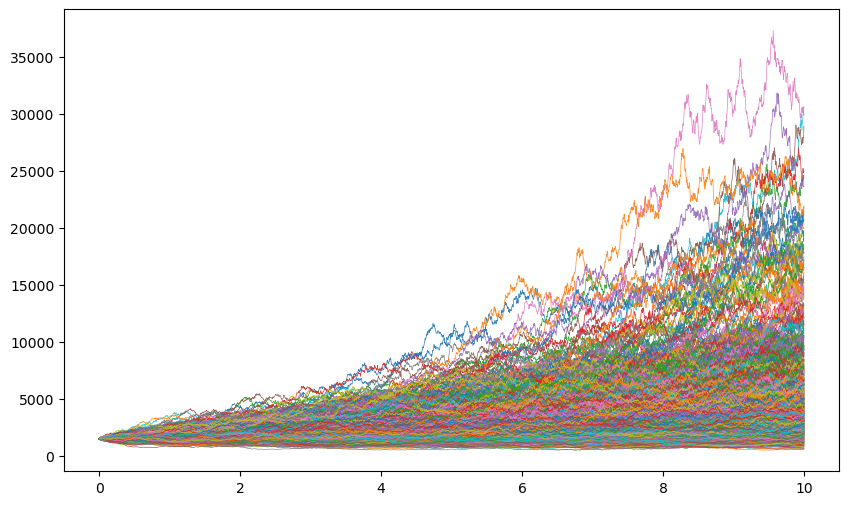

In [722]:
t2 = np.linspace(0, T2, n2 + 1)
plt.figure(figsize=(10, 6))
plt.plot(t2, simulatedGBM.T, lw=.5, alpha=.9)
plt.show()

In [724]:
lastPath=simulatedGBM[-1]

### 1.4 (e)

In [726]:
np.random.seed(1)
GMB_EMM=GBM(r, sigma_hat, T2, P02, n2, N2)

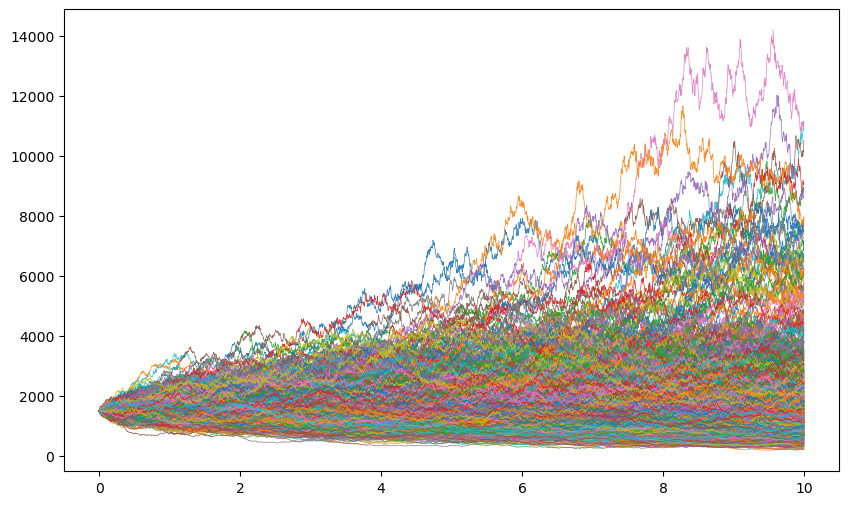

In [728]:
plt.figure(figsize=(10, 6))
plt.plot(t2, GMB_EMM.T, lw=.5, alpha=.9)
plt.show()

In [730]:
lastPathEMM=GMB_EMM[-1]

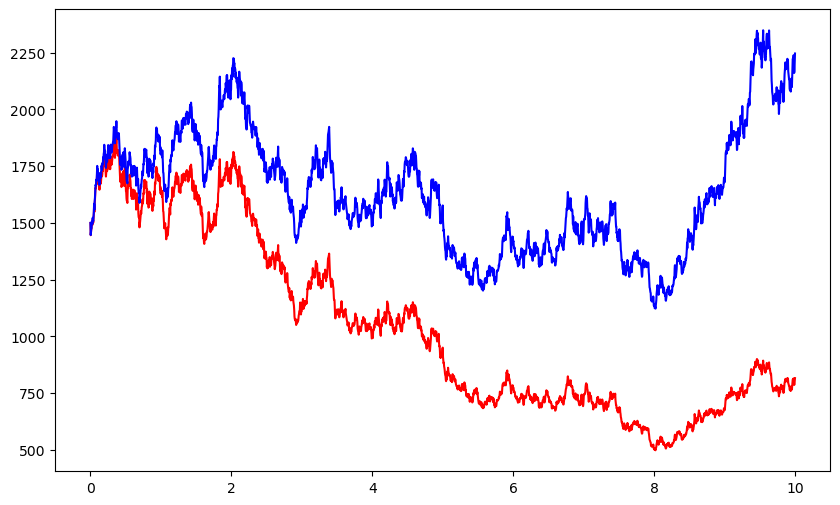

In [738]:
#comparing last line GMB under Q to GMB under Q~
plt.figure(figsize=(10, 6))
plt.plot(t2, lastPathEMM,color="red")
plt.plot(t2, lastPath, color="blue")
plt.show()

### 1.4 (f)

In [764]:
logRet = np.log(lastPath / P02)
logRet_EMM = np.log(lastPathEMM / P02)

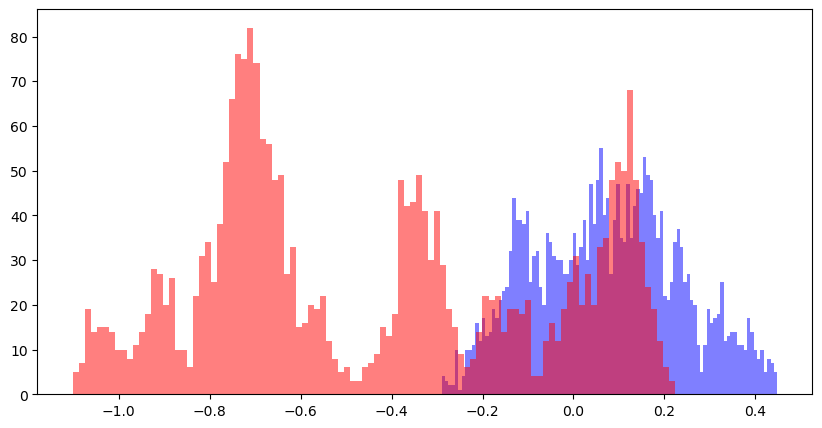

In [767]:
plt.figure(figsize=(10, 5))
plt.hist(logRet, bins=100, alpha=0.5, color='blue')
plt.hist(logRet_EMM, bins=100, alpha=0.5, color='red')
plt.show()

### 1.4 (g)

In [763]:
PtildeQ = GBM(miu_hat - r, sigma_hat, T2, P02, n2, N2)
finalQ1 = PtildeQ[:, -1]

# Martingale, drift = 0
PtildeQ_EMM = GBM(0, sigma_hat, T2, P02, n2, N2)
PtildeQ_EMM = PtildeQ_EMM[:, -1]

logQ1 = np.log(finalQ1 / P02)
logQ_EMM = np.log(PtildeQ_EMM / P02)

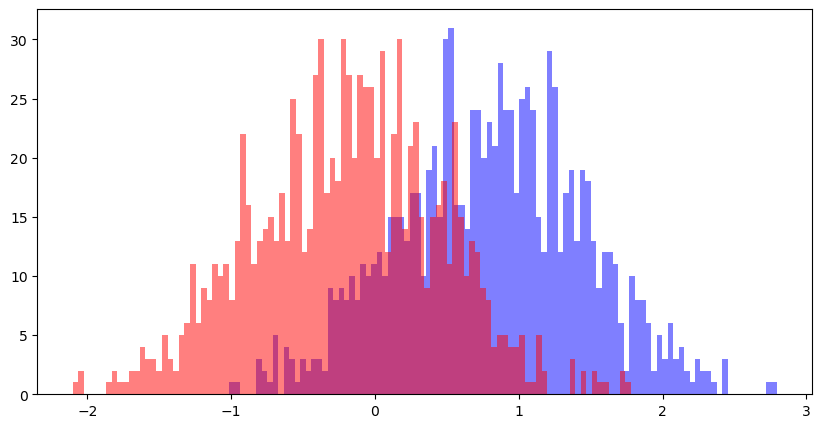

In [771]:
plt.figure(figsize=(10, 5))
plt.hist(logQ1, bins=100, alpha=0.5, color='blue')
plt.hist(logQ_EMM, bins=100, alpha=0.5, color='red')
plt.show()